In [1]:
# 5) Data Analytics II
# 1.	Implement	logistic	regression	using	Python/R	to	perform	classification	on Social_Network_Ads.csv dataset.
# 2.	Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall
# on the given dataset.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [2]:

df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 17.7 KB


In [4]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [5]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
X = df[['Age', 'EstimatedSalary']]
Y = df['Purchased']


In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)


In [8]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [9]:

lm = LogisticRegression()

In [10]:
lm.fit(X_train, Y_train)


LogisticRegression()

In [11]:
y_pred=lm.predict(X_test)

In [12]:

accuracy = accuracy_score(Y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.89


In [13]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



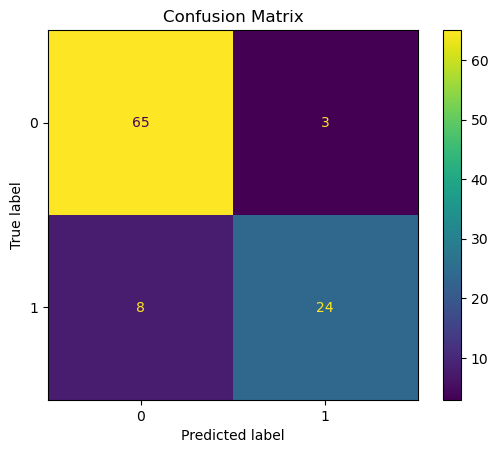

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(Y_test, y_pred)

plt.title("Confusion Matrix")

plt.show()

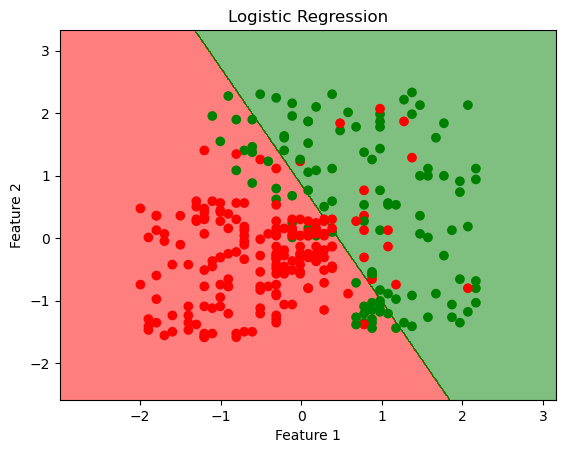

In [15]:

from matplotlib.colors import ListedColormap

# Training data
X_set = X_train
y_set = Y_train

# Mesh grid
X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
    np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01)
)

# Decision boundary
plt.contourf(
    X1,
    X2,
    lm.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.5,
    cmap=ListedColormap(('red', 'green'))
)

# Data points
plt.scatter(
    X_set[:,0],
    X_set[:,1],
    c=y_set,
    cmap=ListedColormap(('red', 'green'))
)

plt.title("Logistic Regression")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()